# Movie Graph Analysis Project



1 - Import Libraries

In [1]:
import pandas as pd
import ast
import networkx as nx
import matplotlib.pyplot as plt

from itertools import combinations
from collections import defaultdict
from networkx.algorithms.community import greedy_modularity_communities

# 1. Load and Explore Dataset



2 - Load Dataset

In [3]:
df = pd.read_csv("transactions.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (610, 2)


,userId,title
0,1,"['toy story (1995)', 'grumpier old men (1995)'..."
1,2,"['shawshank redemption, the (1994)', 'tommy bo..."
2,3,"['dangerous minds (1995)', ""schindler's list (..."
3,4,"['get shorty (1995)', 'twelve monkeys (a.k.a. ..."
4,5,"['toy story (1995)', 'get shorty (1995)', 'bab..."


3 - Inspect Data

In [4]:
print(df.columns)
print(df.dtypes)

Index(['userId', 'title'], dtype='object')
userId     int64
title     object
dtype: object


# 2. Prepare Transactions



4 - Convert Movie Lists

In [5]:
df['title'] = df['title'].apply(ast.literal_eval)

print(type(df['title'][0]))
print(df['title'][0][:5])

<class 'list'>
['toy story (1995)', 'grumpier old men (1995)', 'heat (1995)', 'seven (a.k.a. se7en) (1995)', 'usual suspects, the (1995)']


5 - Check Number of Movies per User

In [6]:
df['movie_count'] = df['title'].apply(len)

print(df['movie_count'].describe())

count     610.000000
mean      165.304918
std       269.480584
min        20.000000
25%        35.000000
50%        70.500000
75%       168.000000
max      2698.000000
Name: movie_count, dtype: float64


6 - Optional Optimization

In [7]:
MAX_MOVIES = 100

df['title'] = df['title'].apply(lambda movies: movies[:MAX_MOVIES])

# 3. Construct Co-Watching Graph



7 - Generate Co-Watching Edge Weights

In [8]:
edge_weights = defaultdict(int)

for movies in df['title']:
    for pair in combinations(sorted(movies), 2):
        edge_weights[pair] += 1

print("Number of edges:", len(edge_weights))

Number of edges: 653080


# 4. Save Graph Data



8 - Convert Edge Weights to DataFrame

In [9]:
graph_data = pd.DataFrame(
    [(m1, m2, w) for (m1, m2), w in edge_weights.items()],
    columns=['movie1', 'movie2', 'weight']
)

graph_data.head()

,movie1,movie2,weight
0,"abyss, the (1989)","adventures of robin hood, the (1938)",1
1,"abyss, the (1989)",alice in wonderland (1951),4
2,"abyss, the (1989)",alien (1979),24
3,"abyss, the (1989)",apocalypse now (1979),10
4,"abyss, the (1989)",austin powers: international man of mystery (1...,12


9 - Remove Weak Edges

In [10]:
MIN_WEIGHT = 2

graph_data = graph_data[graph_data['weight'] >= MIN_WEIGHT]

print("Filtered edges:", graph_data.shape[0])

Filtered edges: 225935


10 - Save Graph Data

In [11]:
graph_data.to_csv("graph_data.csv", index=False)

print("graph_data.csv saved successfully")

graph_data.csv saved successfully


# 5. Build Weighted Graph



11 - Build Weighted Graph

In [12]:
G = nx.Graph()

for _, row in graph_data.iterrows():
    G.add_edge(row['movie1'], row['movie2'], weight=row['weight'])

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 2499
Edges: 225935


# 6. Apply PageRank



12 - Apply PageRank

In [13]:
pagerank_scores = nx.pagerank(G, weight='weight')

13 - Convert PageRank Results to DataFrame

In [14]:
pagerank_df = pd.DataFrame(
    pagerank_scores.items(),
    columns=['movie', 'pagerank']
)

pagerank_df = pagerank_df.sort_values(by='pagerank', ascending=False)

pagerank_df.head(10)

,movie,pagerank
29,forrest gump (1994),0.009127
107,"shawshank redemption, the (1994)",0.008310
58,pulp fiction (1994),0.008179
70,star wars: episode iv - a new hope (1977),0.007070
66,"silence of the lambs, the (1991)",0.006830
43,jurassic park (1993),0.005901
80,toy story (1995),0.005766
13,braveheart (1995),0.005740
461,"matrix, the (1999)",0.005446
82,"usual suspects, the (1995)",0.005374


# 7. Save PageRank Results



14 - Save PageRank Scores

In [15]:
pagerank_df.to_csv("pagerank_scores.csv", index=False)

print("pagerank_scores.csv saved successfully")

pagerank_scores.csv saved successfully


15 - Top Influential Movies

In [16]:
top_movies = pagerank_df.head(10)

print(top_movies)

                                         movie  pagerank
29                         forrest gump (1994)  0.009127
107           shawshank redemption, the (1994)  0.008310
58                         pulp fiction (1994)  0.008179
70   star wars: episode iv - a new hope (1977)  0.007070
66            silence of the lambs, the (1991)  0.006830
43                        jurassic park (1993)  0.005901
80                            toy story (1995)  0.005766
13                           braveheart (1995)  0.005740
461                         matrix, the (1999)  0.005446
82                  usual suspects, the (1995)  0.005374


# 8. Community Detection



16 - Detect Communities

In [17]:
communities = greedy_modularity_communities(G)

print("Number of communities:", len(communities))

Number of communities: 10


17 - Display Sample Communities

In [18]:
for i, community in enumerate(list(communities)[:5]):
    print(f"Community {i+1}:")
    print(list(community)[:10])
    print("-" * 40)

Community 1:
['coyote ugly (2000)', 'glory (1989)', 'double indemnity (1944)', 'lost in translation (2003)', 'last king of scotland, the (2006)', 'fantastic four (2005)', 'speed 2: cruise control (1997)', 'big fish (2003)', 'moana (2016)', 'seventh seal, the (sjunde inseglet, det) (1957)']
----------------------------------------
Community 2:
['blob, the (1958)', 'prefontaine (1997)', 'bad company (1995)', 'secret garden, the (1993)', 'afterglow (1997)', 'go fish (1994)', 'beneath the planet of the apes (1970)', 'twelve monkeys (a.k.a. 12 monkeys) (1995)', 'renaissance man (1994)', 'like water for chocolate (como agua para chocolate) (1992)']
----------------------------------------
Community 3:
['deer hunter, the (1978)', 'scream 2 (1997)', 'jaws 2 (1978)', 'fly, the (1958)', 'touch of evil (1958)', 'perfect candidate, a (1996)', 'nightmare on elm street 4: the dream master, a (1988)', 'hideaway (1995)', 'kolya (kolja) (1996)', 'fly ii, the (1989)']
-----------------------------------

# 9. Graph Visualization



18 - Visualize a Sample Subgraph

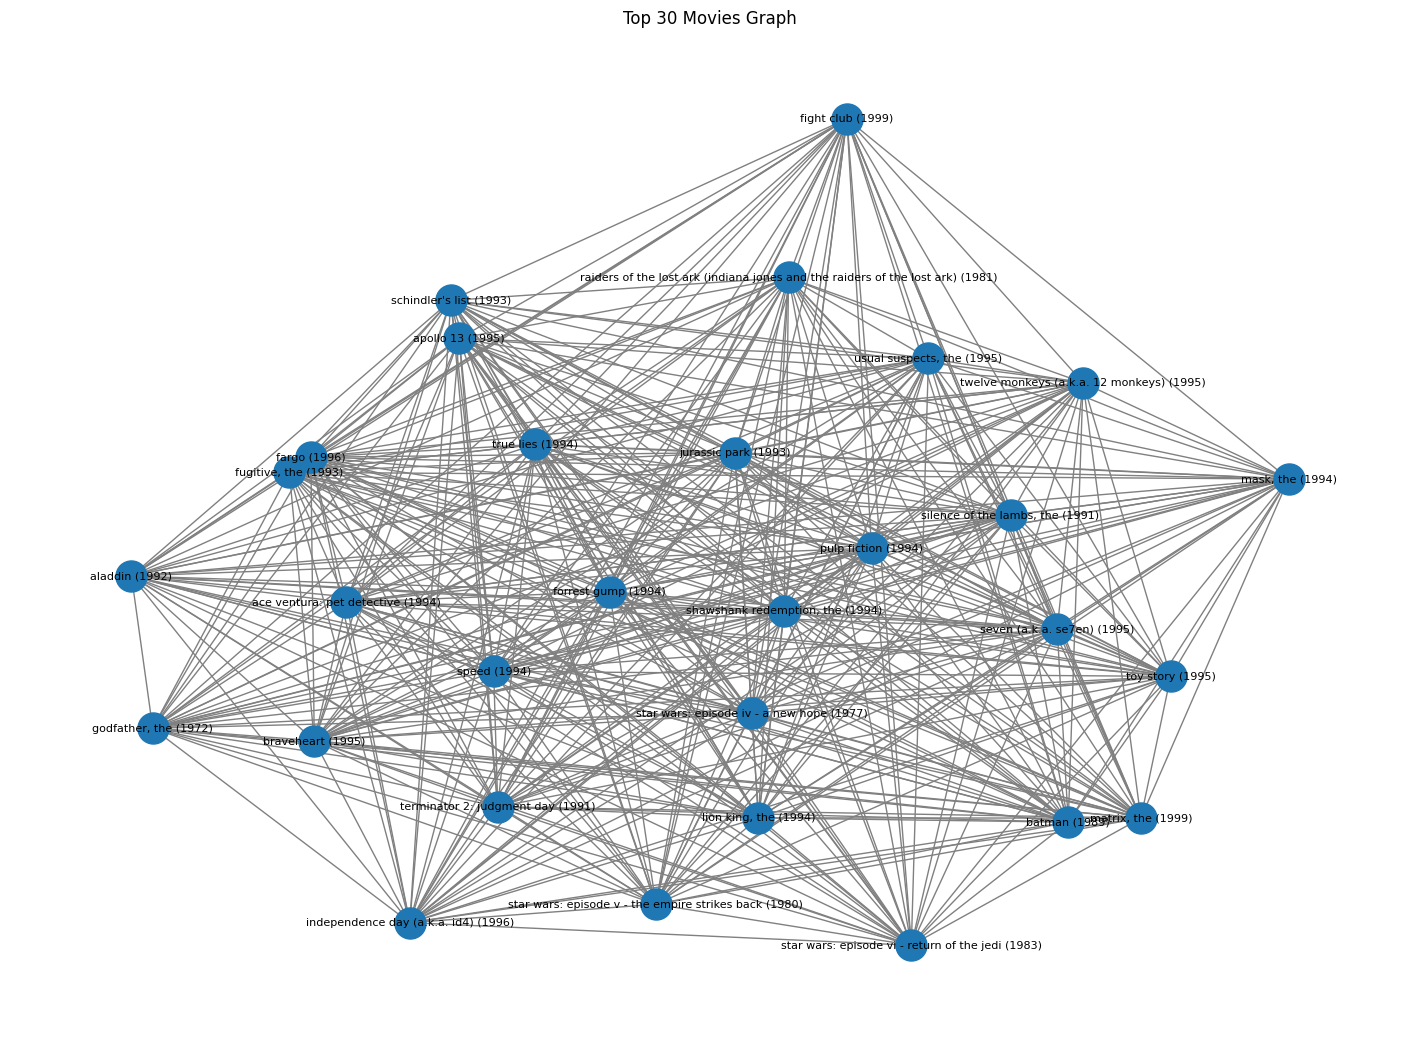

In [19]:
sample_nodes = list(pagerank_df.head(30)['movie'])
subG = G.subgraph(sample_nodes)

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(subG, seed=42)

nx.draw(
    subG,
    pos,
    with_labels=True,
    node_size=500,
    font_size=8,
    edge_color='gray'
)

plt.title("Top 30 Movies Graph")
plt.show()

# 10. Final Summary


19 - Final Summary

In [20]:
print("===== FINAL SUMMARY =====")
print("Users:", len(df))
print("Movies:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Communities:", len(communities))
print("\nTop 10 Influential Movies:")
print(pagerank_df.head(10))

===== FINAL SUMMARY =====
Users: 610
Movies: 2499
Edges: 225935
Communities: 10

Top 10 Influential Movies:
                                         movie  pagerank
29                         forrest gump (1994)  0.009127
107           shawshank redemption, the (1994)  0.008310
58                         pulp fiction (1994)  0.008179
70   star wars: episode iv - a new hope (1977)  0.007070
66            silence of the lambs, the (1991)  0.006830
43                        jurassic park (1993)  0.005901
80                            toy story (1995)  0.005766
13                           braveheart (1995)  0.005740
461                         matrix, the (1999)  0.005446
82                  usual suspects, the (1995)  0.005374
